In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import random
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
dataset_path = 'numpy_data/numpy_bitmap'
CLASS_LEN = 1000
BATCH_SIZE = 32
SEED = 66
EPOCHS = 10
FILES_LEN = 30

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [6]:
files = os.listdir(dataset_path)[:FILES_LEN]
classes = len(files)
print(classes, files)
class_names = []

all_images = []
all_labels = []
for idx, file in enumerate(files):
    class_name = file.replace(' ', '_').replace('.npy', '')
    class_names.append(class_name)
    data = np.load(os.path.join(dataset_path, file)).astype(np.float32)
    data = data[:CLASS_LEN]
    data = data / 255.0
    data = data.reshape(-1, 28, 28)
    all_images.extend(data)
    all_labels.extend([idx] * len(data))

print(f"Total images: {len(all_images)}, Total labels: {classes}")

30 ['aircraft carrier.npy', 'airplane.npy', 'alarm clock.npy', 'ambulance.npy', 'angel.npy', 'animal migration.npy', 'ant.npy', 'anvil.npy', 'apple.npy', 'arm.npy', 'asparagus.npy', 'axe.npy', 'backpack.npy', 'banana.npy', 'bandage.npy', 'barn.npy', 'baseball bat.npy', 'baseball.npy', 'basket.npy', 'basketball.npy', 'bat.npy', 'bathtub.npy', 'beach.npy', 'bear.npy', 'beard.npy', 'bed.npy', 'bee.npy', 'belt.npy', 'bench.npy', 'bicycle.npy']
Total images: 30000, Total labels: 30


In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images,
    all_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=all_labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print(f"Final split sizes:")
print(f"Train: {len(X_train)} ({len(X_train)/len(all_images)*100:.1f}%)")
print(f"Val: {len(X_val)} ({len(X_val)/len(all_images)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(all_images)*100:.1f}%)")

Final split sizes:
Train: 24000 (80.0%)
Val: 3000 (10.0%)
Test: 3000 (10.0%)


In [8]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    # transforms.RandomRotation(15, fill=0),
    # transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), fill=0),
    # transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # grayscale -> 3-channel
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def apply_transform(images, transform, seed=SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    return torch.stack([transform(img) for img in tqdm(images)])

# def apply_transform(images, transform, chunk_size=500, seed=SEED):
#     random.seed(seed)
#     torch.manual_seed(seed)
    
#     all_chunks = []
#     total_images = len(images)
    
#     for i in tqdm(range(0, total_images, chunk_size)):
#         chunk = images[i:min(i+chunk_size, total_images)]
        
#         # Process chunk
#         chunk_tensors = [transform(img) for img in chunk]
#         chunk_tensor = torch.stack(chunk_tensors)
#         all_chunks.append(chunk_tensor)
        
#         # Clear chunk tensors to free memory
#         del chunk_tensors
#         if device.type == 'cuda':
#             torch.cuda.empty_cache()
    
#     # Concatenate all chunks
#     result = torch.cat(all_chunks, dim=0)
    
#     # Clean up
#     del all_chunks
#     import gc
#     gc.collect()
    
#     return result


print("Applying transforms to training set")
X_train_tensor = apply_transform(X_train, train_transform)
print("Applying transforms to validation set")
X_val_tensor = apply_transform(X_val, eval_transform)
print("Applying transforms to test set")
X_test_tensor = apply_transform(X_test, eval_transform)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"\nTensor shapes:")
print(f"  Train: {X_train_tensor.shape}")
print(f"  Val:   {X_val_tensor.shape}")
print(f"  Test:  {X_test_tensor.shape}")

Applying transforms to training set


  0%|          | 0/24000 [00:00<?, ?it/s]

100%|██████████| 24000/24000 [00:31<00:00, 769.91it/s]


Applying transforms to validation set


100%|██████████| 3000/3000 [00:05<00:00, 539.04it/s]


Applying transforms to test set


100%|██████████| 3000/3000 [00:03<00:00, 789.05it/s]



Tensor shapes:
  Train: torch.Size([24000, 3, 224, 224])
  Val:   torch.Size([3000, 3, 224, 224])
  Test:  torch.Size([3000, 3, 224, 224])


In [9]:
g = torch.Generator()
g.manual_seed(SEED)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=(device.type=='cuda'), generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(device.type=='cuda'), generator=g)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(device.type=='cuda'), generator=g)

print(f"Batches: Train {len(train_loader)}, Val {len(val_loader)}, Test {len(test_loader)}")

Batches: Train 750, Val 94, Test 94


In [11]:
num_classes = classes

# Load pretrained model
model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
print("Loaded pretrained ConvNeXt Tiny (ImageNet weights)")

for name, param in model.named_parameters():
    if name.startswith('features.0') or name.startswith('features.1') or name.startswith('features.2'):
        param.requires_grad = False
        print(f"  Frozen: {name}")

# Modify the classifier head
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, num_classes)
)
# model.classifier[2] = nn.Linear(in_features, num_classes)

# TODO: For experiment and better results
# # Initialize the new layer
# nn.init.xavier_uniform_(model.classifier[2].weight)
# nn.init.zeros_(model.classifier[2].bias)

model = model.to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loaded pretrained ConvNeXt Tiny (ImageNet weights)
  Frozen: features.0.0.weight
  Frozen: features.0.0.bias
  Frozen: features.0.1.weight
  Frozen: features.0.1.bias
  Frozen: features.1.0.layer_scale
  Frozen: features.1.0.block.0.weight
  Frozen: features.1.0.block.0.bias
  Frozen: features.1.0.block.2.weight
  Frozen: features.1.0.block.2.bias
  Frozen: features.1.0.block.3.weight
  Frozen: features.1.0.block.3.bias
  Frozen: features.1.0.block.5.weight
  Frozen: features.1.0.block.5.bias
  Frozen: features.1.1.layer_scale
  Frozen: features.1.1.block.0.weight
  Frozen: features.1.1.block.0.bias
  Frozen: features.1.1.block.2.weight
  Frozen: features.1.1.block.2.bias
  Frozen: features.1.1.block.3.weight
  Frozen: features.1.1.block.3.bias
  Frozen: features.1.1.block.5.weight
  Frozen: features.1.1.block.5.bias
  Frozen: features.1.2.layer_scale
  Frozen: features.1.2.block.0.weight
  Frozen: features.1.2.block.0.bias
  Frozen: features.1.2.block.2.weight
  Frozen: features.1.2.b

In [12]:
criterion = nn.CrossEntropyLoss()

# TODO: For experiment and better results
# # Use different learning rates for pretrained backbone and new classifier
# pretrained_params = []
# classifier_params = []
# for name, param in model.named_parameters():
#     if 'classifier' in name:
#         classifier_params.append(param)
#     else:
#         pretrained_params.append(param)

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05)

# Cosine annealing scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validating')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / len(loader), 100. * correct / total, all_preds, all_labels

In [15]:
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")
print("="*60)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'categories': class_names
        }, 'best_model.pth')
        print(f"✓ New best model saved! (Val Acc: {val_acc:.2f}%)")

    print("="*100)

print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.2f}%")

Starting training...

Epoch 1/10


Validating: 100%|██████████| 94/94 [00:14<00:00,  6.36it/s]



Train Loss: 1.2738 | Train Acc: 63.54%
Val Loss:   0.7614 | Val Acc:   79.23%
LR: 0.000976
✓ New best model saved! (Val Acc: 79.23%)

Epoch 2/10


Validating: 100%|██████████| 94/94 [00:14<00:00,  6.33it/s]



Train Loss: 0.6848 | Train Acc: 81.26%
Val Loss:   0.6749 | Val Acc:   81.37%
LR: 0.000905
✓ New best model saved! (Val Acc: 81.37%)

Epoch 3/10


...


Train Loss: 0.0598 | Train Acc: 98.21%
Val Loss:   0.7778 | Val Acc:   85.30%
LR: 0.000095
✓ New best model saved! (Val Acc: 85.30%)

Epoch 9/10


Validating: 100%|██████████| 94/94 [00:14<00:00,  6.52it/s]



Train Loss: 0.0275 | Train Acc: 99.25%
Val Loss:   0.7957 | Val Acc:   85.47%
LR: 0.000024
✓ New best model saved! (Val Acc: 85.47%)

Epoch 10/10


Validating: 100%|██████████| 94/94 [00:14<00:00,  6.64it/s]


Train Loss: 0.0158 | Train Acc: 99.61%
Val Loss:   0.8075 | Val Acc:   85.47%
LR: 0.000000

Training complete! Best validation accuracy: 85.47%


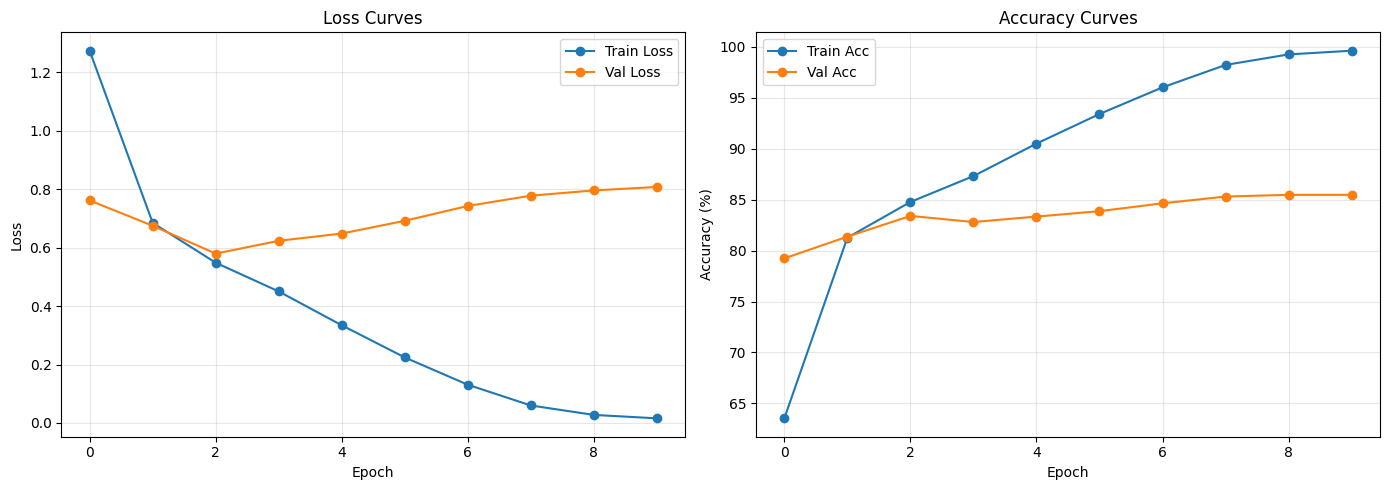

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'], label='Val Acc', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
categories = []
for idx, file in enumerate(files):
    class_name = file.replace(' ', '_').replace('.npy', '')
    categories.append(class_name)

models = ['model_epoc3', 'model_epoc6', 'model_epoc7', 'model_epoc8', 'model_epoc9']
for model_name in models:
    checkpoint = torch.load(f'{model_name}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded {model_name} from epoch {checkpoint['epoch']+1} (Val Acc: {checkpoint['val_acc']:.2f}%)")

    test_loss, test_acc, test_preds, test_labels = validate_one_epoch(
        model, test_loader, criterion, device
    )

    print(f"Test Results:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("Classification Report:")
    print(classification_report(test_labels, test_preds, target_names=categories, digits=4))
    print("="*40)

Loaded model_epoc3 from epoch 3 (Val Acc: 83.40%)


Validating: 100%|██████████| 94/94 [00:14<00:00,  6.61it/s]


Test Results:
Test Loss: 0.6004
Test Accuracy: 83.07%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.6098    0.5000    0.5495       100
        airplane     0.8913    0.8200    0.8542       100
     alarm_clock     0.8687    0.8600    0.8643       100
       ambulance     0.9670    0.8800    0.9215       100
           angel     0.8558    0.8900    0.8725       100
animal_migration     0.6981    0.7400    0.7184       100
             ant     0.8190    0.8600    0.8390       100
           anvil     0.8878    0.8700    0.8788       100
           apple     0.9785    0.9100    0.9430       100
             arm     0.7705    0.9400    0.8468       100
       asparagus     0.8632    0.8200    0.8410       100
             axe     0.8990    0.8900    0.8945       100
        backpack     0.8073    0.8800    0.8421       100
          banana     0.8435    0.9700    0.9023       100
         bandage     0.8667    0.7800    0.8211     

Validating: 100%|██████████| 94/94 [00:12<00:00,  7.37it/s]


Test Results:
Test Loss: 0.6864
Test Accuracy: 83.23%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.5795    0.5100    0.5426       100
        airplane     0.8713    0.8800    0.8756       100
     alarm_clock     0.9022    0.8300    0.8646       100
       ambulance     0.9293    0.9200    0.9246       100
           angel     0.8381    0.8800    0.8585       100
animal_migration     0.6542    0.7000    0.6763       100
             ant     0.8224    0.8800    0.8502       100
           anvil     0.8070    0.9200    0.8598       100
           apple     0.9135    0.9500    0.9314       100
             arm     0.9277    0.7700    0.8415       100
       asparagus     0.8571    0.8400    0.8485       100
             axe     0.9565    0.8800    0.9167       100
        backpack     0.8958    0.8600    0.8776       100
          banana     0.8348    0.9600    0.8930       100
         bandage     0.8144    0.7900    0.8020     

...

Test Results:
Test Loss: 0.7400
Test Accuracy: 84.30%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.6386    0.5300    0.5792       100
        airplane     0.8142    0.9200    0.8638       100
     alarm_clock     0.9101    0.8100    0.8571       100
       ambulance     0.9300    0.9300    0.9300       100
           angel     0.8700    0.8700    0.8700       100
animal_migration     0.5526    0.8400    0.6667       100
             ant     0.8913    0.8200    0.8542       100
           anvil     0.9020    0.9200    0.9109       100
           apple     0.8818    0.9700    0.9238       100
             arm     0.8246    0.9400    0.8785       100
       asparagus     0.8438    0.8100    0.8265       100
             axe     0.9468    0.8900    0.9175       100
        backpack     0.9082    0.8900    0.8990       100
          banana     0.8276    0.9600    0.8889       100
         bandage     0.8431    0.8600    0.8515     

Validating: 100%|██████████| 94/94 [00:12<00:00,  7.45it/s]


Test Results:
Test Loss: 0.7619
Test Accuracy: 85.23%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.5567    0.5400    0.5482       100
        airplane     0.8257    0.9000    0.8612       100
     alarm_clock     0.8958    0.8600    0.8776       100
       ambulance     0.9300    0.9300    0.9300       100
           angel     0.8700    0.8700    0.8700       100
animal_migration     0.7660    0.7200    0.7423       100
             ant     0.7778    0.9100    0.8387       100
           anvil     0.9029    0.9300    0.9163       100
           apple     0.9596    0.9500    0.9548       100
             arm     0.8142    0.9200    0.8638       100
       asparagus     0.8723    0.8200    0.8454       100
             axe     0.9574    0.9000    0.9278       100
        backpack     0.8900    0.8900    0.8900       100
          banana     0.9592    0.9400    0.9495       100
         bandage     0.8333    0.8500    0.8416     

Validating: 100%|██████████| 94/94 [00:12<00:00,  7.34it/s]

Test Results:
Test Loss: 0.7815
Test Accuracy: 85.83%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.5268    0.5900    0.5566       100
        airplane     0.8947    0.8500    0.8718       100
     alarm_clock     0.8854    0.8500    0.8673       100
       ambulance     0.8942    0.9300    0.9118       100
           angel     0.8990    0.8900    0.8945       100
animal_migration     0.6937    0.7700    0.7299       100
             ant     0.8396    0.8900    0.8641       100
           anvil     0.8846    0.9200    0.9020       100
           apple     0.9596    0.9500    0.9548       100
             arm     0.8800    0.8800    0.8800       100
       asparagus     0.9247    0.8600    0.8912       100
             axe     0.9681    0.9100    0.9381       100
        backpack     0.9000    0.9000    0.9000       100
          banana     0.9794    0.9500    0.9645       100
         bandage     0.8600    0.8600    0.8600     

In [ ]:
print("\n📋 Classification Report:")
print("="*70)
print(classification_report(test_labels, test_preds, target_names=classes, digits=4))